In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import nltk
import re
import string

#nltk.download("stopwords")

In [2]:
df=pd.read_csv("train_amazon.csv")
df.head()

,Unnamed: 0,overall,verified,asin,style,reviewerName,reviewText,summary,description,title,rank,main_cat
0,4359171,5.0,True,B002TLT10I,{'Product Packaging:': ' Standard Packaging'},Catherine Hynes,Love these things. The supplied batteries wer...,Good headset Replaced batteries,"[""Wireless headphones come in many shapes and ...",Sennheiser RS 170 Digital Wireless Headphones ...,"['>#132,147 in Cell Phones & Accessories (See ...",Home Audio & Theater
1,3938786,5.0,True,B001UQ6E3K,{'Style:': ' 20-60x60'},rschoepke,"great value, good range and easy to use",Five Stars,['The 60 mm Waterproof UpClose Spotting Scope ...,Celestron 52229 60mm Refractor Zoom Spotting S...,"['>#20,943 in Camera & Photo (See Top 100 in C...",Camera & Photo
2,6176764,5.0,True,B005FYNSUA,{'Capacity:': ' 16 GB'},Carl,Smallest thumb drive ever! Can't beat the price,Five Stars,"[""With its low-profile design, the Cruzer Fit ...",SanDisk Cruzer Fit 8GB USB 2.0 Low-Profile Fla...,['>#326 in Computers & Accessories > Data Stor...,All Electronics
3,1546547,5.0,True,B0007ZFLYI,NaN,Scott W. Soyster,I bought this webcam mostly because of the pri...,Not a bad webcam for the price.,"[""When you rely on your notebook PC to communi...",Logitech Quickcam for Notebooks Deluxe,"['>#1,108 in Electronics &gt; Accessories &amp...",All Electronics
4,3178737,5.0,True,B0016JMS90,NaN,Dancer,I got this for my mom. She's not the most tec...,Good webcam,"['PC Webcam with Built-In Microphone', 'Add tr...",Logitech QuickCam Communicate MP (Black),['>#381 in Electronics > Accessories & Supplie...,All Electronics


In [3]:
df['brand']=df['title'].str.split(expand=True)[0]

<Axes: xlabel='brand'>

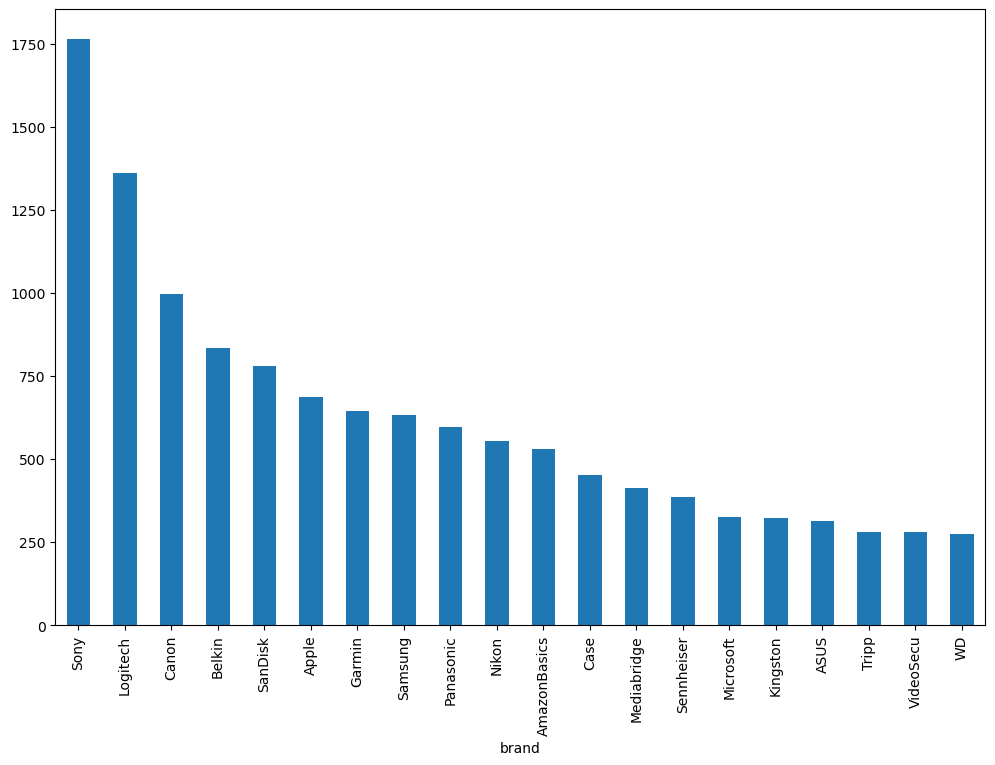

In [4]:
plt.figure(figsize=(12,8))
df['brand'].value_counts()[:20].plot.bar()

In [5]:
df_train=df[['reviewText','summary','overall']]
df_train.head()

,reviewText,summary,overall
0,Love these things. The supplied batteries wer...,Good headset Replaced batteries,5.0
1,"great value, good range and easy to use",Five Stars,5.0
2,Smallest thumb drive ever! Can't beat the price,Five Stars,5.0
3,I bought this webcam mostly because of the pri...,Not a bad webcam for the price.,5.0
4,I got this for my mom. She's not the most tec...,Good webcam,5.0


In [6]:
df_train['overall'].value_counts()

overall
5.0    30010
4.0     8429
1.0     5222
3.0     3729
2.0     2610
Name: count, dtype: int64

In [7]:
#droping the NaN 

df_train=df_train.dropna(axis=0,subset=['reviewText'])

In [8]:
def classify(x):
    if x==5.0 or x==4.0:
        return 3
    elif x==3.0:
        return 2
    else:
        return 1
    

In [9]:
df_train['Sentiment']=df_train['overall'].apply(classify)

In [10]:
df_train['Sentiment'].value_counts()

Sentiment
3    38423
1     7831
2     3728
Name: count, dtype: int64

In [11]:
df_train.head()

,reviewText,summary,overall,Sentiment
0,Love these things. The supplied batteries wer...,Good headset Replaced batteries,5.0,3
1,"great value, good range and easy to use",Five Stars,5.0,3
2,Smallest thumb drive ever! Can't beat the price,Five Stars,5.0,3
3,I bought this webcam mostly because of the pri...,Not a bad webcam for the price.,5.0,3
4,I got this for my mom. She's not the most tec...,Good webcam,5.0,3


In [12]:
#Text preprocessing

def remove_punctuation(text):
    no_punct=[words for words in text if words not in string.punctuation]
    words_wo_punct="".join(no_punct)
    return words_wo_punct

In [13]:
#df_train['reviewText']=df_train['reviewText'].apply(remove_punctuation)

In [14]:
df_train.head()

,reviewText,summary,overall,Sentiment
0,Love these things. The supplied batteries wer...,Good headset Replaced batteries,5.0,3
1,"great value, good range and easy to use",Five Stars,5.0,3
2,Smallest thumb drive ever! Can't beat the price,Five Stars,5.0,3
3,I bought this webcam mostly because of the pri...,Not a bad webcam for the price.,5.0,3
4,I got this for my mom. She's not the most tec...,Good webcam,5.0,3


In [15]:
df['reviewText']

0        Love these things.  The supplied batteries wer...
1                  great value, good range and easy to use
2          Smallest thumb drive ever! Can't beat the price
3        I bought this webcam mostly because of the pri...
4        I got this for my mom.  She's not the most tec...
                               ...                        
49995    I had e2c's, and the wires started to crack (t...
49996                                        Works great!!
49997    I used it as an adapter for the keyboard that ...
49998    This is a good overall protective lens.  Used ...
49999    I expect Tiffen filters to be good.  So no dis...
Name: reviewText, Length: 50000, dtype: object

In [16]:
def text_processing(df):
    df['reviewText']=df['reviewText'].apply(lambda x:remove_punctuation(x.lower()))
    df['reviewText'] = df['reviewText'].apply(lambda x:re.sub("[^A-Za-z]", " " , x))
    #stemmer=PorterStemmer()
    ls=nltk.WordNetLemmatizer()
    words=stopwords.words("english")
    df['cleaned_reviews']=df['reviewText'].apply(lambda x:" ".join([ls.lemmatize(i) for i in x.split() if i not in words]).lower())
    return df

In [17]:
df_final=text_processing(df_train)

In [18]:
df_final.head()

,reviewText,summary,overall,Sentiment,cleaned_reviews
0,love these things the supplied batteries were...,Good headset Replaced batteries,5.0,3,love thing supplied battery dead replaced
1,great value good range and easy to use,Five Stars,5.0,3,great value good range easy use
2,smallest thumb drive ever cant beat the price,Five Stars,5.0,3,smallest thumb drive ever cant beat price
3,i bought this webcam mostly because of the pri...,Not a bad webcam for the price.,5.0,3,bought webcam mostly price fact logitech prett...
4,i got this for my mom shes not the most tech ...,Good webcam,5.0,3,got mom shes tech savvy set shes problem one t...


In [19]:
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

from textblob import TextBlob

ModuleNotFoundError: No module named 'wordcloud'

In [ ]:
df_final['Classes']=df_final['Sentiment']
df_final['Classes'].replace({3 : "Positive",
                             2 : "Neutral",
                             1 : "Negative"},
                           inplace=True)

df_final['Classes'].value_counts()

In [ ]:
df_final=df_final.dropna(subset=['cleaned_reviews'])

In [ ]:
df_final.head()

In [ ]:
import warnings
warnings.filterwarnings("ignore")
sns.countplot(df_final['Classes']).set(xlabel="Sentiment", ylabel = "Count");

In [ ]:
df_final['Classes'].value_counts(normalize=True)*100

In [ ]:
Stopwords=set(STOPWORDS)

def word_cloud(data):
    wordcloud=WordCloud(
    background_color="black",
    max_font_size=40,
    max_words=200,
    stopwords=nltk.corpus.stopwords.words('english')
    ).generate(str(data))
    plt.figure(figsize=(15,10))
    plt.axis("off")
    plt.imshow(wordcloud)
    plt.show()

In [ ]:
print("Wordcloud for Neutral")
word_cloud(df_final[df_final['Classes']=="Neutral"]['cleaned_reviews'])

In [ ]:
print("Wordcloud for Negative")
word_cloud(df_final[df_final['Classes']=="Negative"]['cleaned_reviews'])

In [ ]:
print("Wordcloud for Positive")
word_cloud(df_final[df_final['Classes']=="Positive"]['cleaned_reviews'])

In [29]:
df_final['Polarity']=df_final['cleaned_reviews'].apply(lambda x : TextBlob(str(x)).sentiment.polarity)

In [30]:
df_final.head()

,reviewText,summary,overall,Sentiment,cleaned_reviews,Classes,Polarity
0,love these things the supplied batteries were...,Good headset Replaced batteries,5.0,3,love thing supplied battery dead replaced,Positive,0.150000
1,great value good range and easy to use,Five Stars,5.0,3,great value good range easy use,Positive,0.644444
2,smallest thumb drive ever cant beat the price,Five Stars,5.0,3,smallest thumb drive ever cant beat price,Positive,0.000000
3,i bought this webcam mostly because of the pri...,Not a bad webcam for the price.,5.0,3,bought webcam mostly price fact logitech prett...,Positive,0.258272
4,i got this for my mom shes not the most tech ...,Good webcam,5.0,3,got mom shes tech savvy set shes problem one t...,Positive,0.281027


In [31]:
df_final['Polarity']

0        0.150000
1        0.644444
2        0.000000
3        0.258272
4        0.281027
           ...   
49995    0.145374
49996    0.800000
49997   -0.500000
49998    0.220000
49999    0.375000
Name: Polarity, Length: 49984, dtype: float64

Text(0.5, 1.0, 'Sentiment Distribution')

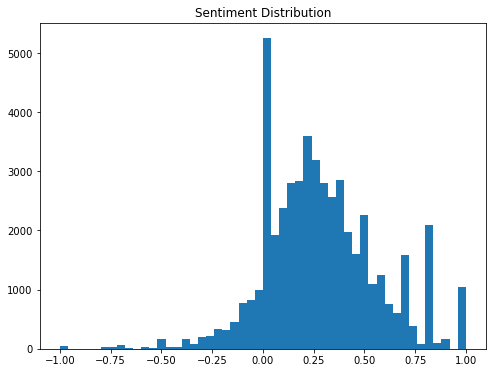

In [32]:
plt.figure(figsize=(8,6))

plt.hist(df_final['Polarity'],bins=50)
plt.title("Sentiment Distribution")

In [33]:
#Advance Visualisation

def get_top_n_bigram(corpus,n=None):
    vec=CountVectorizer(ngram_range=(2,2),stop_words='english').fit(corpus)
    bag_of_words=vec.transform(corpus)
    sum_words=bag_of_words.sum(axis=0)
    words_freq=[(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
    words_freq=sorted(words_freq,key = lambda x: x[1],reverse=True)
    return words_freq[:n]


common_words_good=get_top_n_bigram(df_final[df_final['Classes']=="Positive"]['cleaned_reviews'],8)
common_words_neutral=get_top_n_bigram(df_final[df_final['Classes']=="Neutral"]['cleaned_reviews'],8)
common_words_bad=get_top_n_bigram(df_final[df_final['Classes']=="Negative"]['cleaned_reviews'],8)

In [34]:
def n_gram_plot(data,title,color):
    x=[x[0] for x in data]
    y=[x[1] for x in data]
    sns.barplot(y,x,color='{}'.format(color))
    plt.title('{}'.format(title))

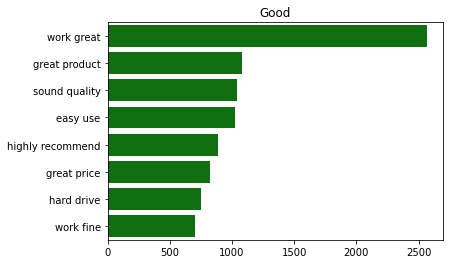

In [35]:
n_gram_plot(common_words_good,"Good","green")

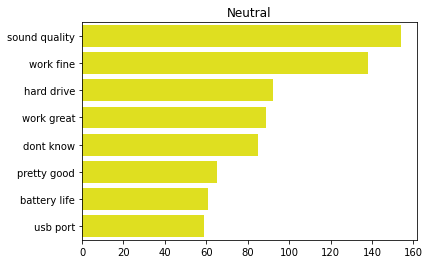

In [36]:
n_gram_plot(common_words_neutral,"Neutral","yellow")

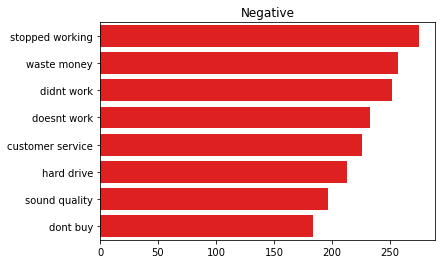

In [37]:
n_gram_plot(common_words_bad,"Negative","red")

In [38]:
df_final.head()

,reviewText,summary,overall,Sentiment,cleaned_reviews,Classes,Polarity
0,love these things the supplied batteries were...,Good headset Replaced batteries,5.0,3,love thing supplied battery dead replaced,Positive,0.150000
1,great value good range and easy to use,Five Stars,5.0,3,great value good range easy use,Positive,0.644444
2,smallest thumb drive ever cant beat the price,Five Stars,5.0,3,smallest thumb drive ever cant beat price,Positive,0.000000
3,i bought this webcam mostly because of the pri...,Not a bad webcam for the price.,5.0,3,bought webcam mostly price fact logitech prett...,Positive,0.258272
4,i got this for my mom shes not the most tech ...,Good webcam,5.0,3,got mom shes tech savvy set shes problem one t...,Positive,0.281027


In [39]:
df_final.columns

Index(['reviewText', 'summary', 'overall', 'Sentiment', 'cleaned_reviews',
       'Classes', 'Polarity'],
      dtype='object')

In [40]:
X=df_final['cleaned_reviews']
y=df_final['Sentiment']

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest,chi2

tfidf = TfidfVectorizer(ngram_range=(1, 1))
rfc = RandomForestClassifier(class_weight="balanced")

In [43]:
text_classifier_Random_Forest=Pipeline([("vect",tfidf),("chi", SelectKBest(chi2,k=1200)),("clf",rfc)])

def run_model(text_classifier):
    print(text_classifier)
    classifier_model=text_classifier.fit(X_train,y_train)
    print(np.mean(classifier_model.predict(X_test)==y_test))

In [44]:
run_model(text_classifier_Random_Forest)

Pipeline(steps=[('vect', TfidfVectorizer()),
                ('chi',
                 SelectKBest(k=1200,
                             score_func=<function chi2 at 0x000002151D7AED08>)),
                ('clf', RandomForestClassifier(class_weight='balanced'))])
0.8183085783570779


In [69]:
# n_estimator=[100,150,200]

# Scores=[]

# for i in n_estimator:
#     clf=text_classifier_Random_Forest=Pipeline([("vect",tfidf),("chi", SelectKBest(chi2,k=1200)),
#                                                 ("clf",RandomForestClassifier(n_estimators=i))])
    
#     classifier_model=clf.fit(X_train,y_train)
#     Scores.append(np.mean(classifier_model.predict(X_test)==y_test))

In [70]:
# from sklearn.naive_bayes import MultinomialNB

# alpha=[0.1,0.001,0.02,0.002]

# Scores=[]

# for i in alpha:
#     clf=Pipeline([("vect",tfidf),("chi", SelectKBest(chi2,k=1200)),
#                                                 ("clf",MultinomialNB(alpha=i))])
    
#     classifier_model=clf.fit(X_train,y_train)
#     Scores.append(np.mean(classifier_model.predict(X_test)==y_test))

In [71]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier()
text_classifier_gradient=Pipeline([("vect",tfidf),("chi", SelectKBest(chi2,k=1200)),("gbc",gbc)])
run_model(text_classifier_gradient)

Pipeline(steps=[('vect', TfidfVectorizer()),
                ('chi',
                 SelectKBest(k=1200,
                             score_func=<function chi2 at 0x0000011BAE25F2F0>)),
                ('gbc', GradientBoostingClassifier())])
0.8171567141558048


In [72]:
conut_vect=CountVectorizer(ngram_range=(2, 2))

text_classifier_Random_Forest_vect=Pipeline([("vect",conut_vect),("chi", SelectKBest(chi2,k=500)),("clf",rfc)])
run_model(text_classifier_Random_Forest_vect)

Pipeline(steps=[('vect', CountVectorizer(ngram_range=(2, 2))),
                ('chi',
                 SelectKBest(k=500,
                             score_func=<function chi2 at 0x0000011BAE25F2F0>)),
                ('clf', RandomForestClassifier(class_weight='balanced'))])
0.7692634131555016


In [45]:
def prediction(review):
    prediction_df=pd.DataFrame([[review,0]],columns=["reviewText","y"])
    prediction_df=text_processing(prediction_df)
    predictions_pred=text_classifier_Random_Forest.predict(prediction_df['cleaned_reviews'])
    return predictions_pred[0]

In [46]:
prediction("This product ")

1